Introduction and general goal of this study:
The Footprint Identification Technique (FIT) is a method used to identify individual animals based on their footprints. It also enables the extraction and modeling of additional information such as the sex of the animal that left the footprint.
FIT is currently available as a free add-in for the JMP statistical software and has been custom-tailored for several endangered species. The aim of this dissertation was to establish FIT for the Eurasian otter and benchmark its classification capabilities against those previously published for other species.
This initial analysis was conducted using JMP. However, throughout the workflow, several limitations became evident—particularly regarding automation capabilities for experiments involving modified workflows and the reproducibility of annotated images.
Due to these limitations, the decision was made to transfer the methodology to a Python package, which will be open source and publicly available once the results are published.
The aim of this package is to
1.	replicate the original workflow and analyses of the JMP add-in
2.	optimize the approach for automation
3.	provide flexibility in terms of methodological components and explore whether modifications at various analysis stages lead to improved FIT models.
Although the main aim remained to develop this technique for Eurasian otters all experiments where conducted on several datasets so that the results for otters where always benchmarked with other established species. The following paragraph describes the methodology and the graphs and tables generated at each step.
@GTP
We are going to create a notebook that primarily builds on my existing codebase to generate a complete workflow for the analysis. Your task is to continuously generate tasks that build upon one another. The final goal is to create a notebook that runs the entire process for sex modeling and individual identification and benchmarking—from data loading all the way to validation on the test set and inference prediction on the inference set (if available). I will always post the introduction and a few Notebook cells that are to build next  It will use softcoded variables of config whererver possible;
The notebook will be called FIT_start_to_finish.ipynb All generate files and graphs will be saved in a separate experiment folder that are not uploaded to github. @ gtp create a markdown that describes all steps of this analyses. For every new entry add a markdown entry to this file.


In [1]:
from pathlib import Path
import os
import pandas as pd

# Determine experiment root dynamically
EXPERIMENT_ROOT = Path(os.getenv('FIT_EXPERIMENT_ROOT', Path.cwd())).resolve()
while not (EXPERIMENT_ROOT / 'data').exists() and EXPERIMENT_ROOT != EXPERIMENT_ROOT.parent:
    EXPERIMENT_ROOT = EXPERIMENT_ROOT.parent

DATA_DIR = EXPERIMENT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
CLEANED_DIR = DATA_DIR / 'cleaned'
SPLITS_DIR = DATA_DIR / 'splits'

RESULTS_DIR = EXPERIMENT_ROOT / 'results'
RESULTS_DATA_DIR = RESULTS_DIR / 'data'

from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview
from FIT_python.data_split_and_summary.data_import_wrapper import DataImportWrapper
from FIT_python.Visualisations.plots_utils import (
    plot_feature_correlation_matrix,
    plot_sex_boxplots,
    plot_individual_boxplots,
    make_marker_map,
    plot_umap_by_individual,
    select_top_features,
)
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

os.chdir(EXPERIMENT_ROOT)
EXP_DIR = RESULTS_DIR / 'experiments' / 'fit_start_to_finish'
EXP_DIR.mkdir(parents=True, exist_ok=True)



Before any train/test splits, a summary table of all analyzed datasets is generated and saved.
Columns:
• Species (Cummonn amen & Latin name) @ gtp you might need a helper dictionary here to consistently right common name and latin name (you can map species labes from the dataset to match style for a research paper)
• No. of footprints [Number of obeseravtions in df • 
No. of known individuals df[individual_id] (after renaming from the original animal coulum check load and split utils)

 No. of trails ( count df[“trails].unique
• No. of measurements ( count number of feature colums Measurements consist of any columns beginning with “V”, “Area”, “dist”, “ang” or “T”, depending on the dataset. Use existing data-loading scripts and feature definitions where possible. Be flexible for groß und kleinschreibung depindig whether data sanatize is already conducted here or not)


In [2]:
overview_df = generate_dataset_overview(RAW_DIR, EXP_DIR/'dataset_overview.csv', reuse_csv=True)
overview_df

,Species,No. of footprints,No. of known individuals,No. of trails,No. of measurements
0,Amur Tiger (Panthera tigris altaica),605,44,86,128
1,Bengal Tiger (Panthera tigris tigris),586,40,87,128
2,Cheetah (Acinonyx jubatus),781,38,110,135
3,Eurasian Otter (Lutra lutra),628,42,80,205


In [3]:
#DataImportWrapper().clean_all()


Training and Test splits and inference splits
For both sex‐classification and individual‐identification models, the captive dataset of known individuals was randomly divided into training and validation subsets using a script‐based, group‐stratified sampling procedure with a fixed random seed to ensure reproducibility. Stratification guaranteed an even sex ratio across both splits, while grouping by animal prevented any overlap of individuals between training and testset.  Additional Validation folds were created and assigned and later used for hyperparameter optimization.
For the Otters a custom script for generating the folds was used making sure, that dna validated field prints only appeared in the testset, additionally since we had a set of prints in Sand and a set of prints in mud available we made sure that an equal number of individuals of both sexes are present in the testset.


Loading:   0%|          | 0/4 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/4 [00:00<?, ?it/s]

Converting:   0%|          | 0/4 [00:00<?, ?it/s]

Splitting datasets:   0%|          | 0/4 [00:00<?, ?it/s]

↪️  Verwende bestehende Splits für amur_tiger
↪️  Verwende bestehende Splits für bengal_tiger
↪️  Verwende bestehende Splits für cheetah
↪️  Verwende bestehende Splits für eurasian_otter


...


[DEBUG] compute_summary called for bengal_tiger/inference, df shape = (38, 133)
[DEBUG] ds_label = bengal_tiger Inference
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['panthera_tigris_tigris']
[DEBUG] species_code = panthera tigris tigris
[DEBUG] sex value counts:
sex
Unknown    38
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (0, 133)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Male, subset shape = (0, 133)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Unknown, subset shape = (38, 133)
[DEBUG]  n_fp=38, n_ind=6, n_tr=7
[DEBUG]   fp_per_ind summary: mean=6.333333333333333, sd=1.9720265943665387
[DEBUG]   tr_per_ind summary: mean=1.1666666666666667, sd=0.37267799624996495
[DEBUG] Returning summary DataFrame with shape (3, 10)

[DEBUG] compute_summary called for bengal_tiger/test, 

Splits:   0%|          | 0/3 [00:00<?, ?it/s]


[DEBUG] compute_summary called for cheetah/inference, df shape = (0, 141)
[DEBUG] df is empty, returning empty summary

[DEBUG] compute_summary called for cheetah/test, df shape = (158, 141)
[DEBUG] ds_label = cheetah Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['acinonyx_jubatus']
[DEBUG] species_code = acinonyx jubatus
[DEBUG] sex value counts:
sex
Male      92
Female    66
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (66, 141)
[DEBUG]  n_fp=66, n_ind=3, n_tr=10
[DEBUG]   fp_per_ind summary: mean=22.0, sd=2.943920288775949
[DEBUG]   tr_per_ind summary: mean=3.3333333333333335, sd=0.4714045207910317
[DEBUG] sex = Male, subset shape = (92, 141)
[DEBUG]  n_fp=92, n_ind=5, n_tr=13
[DEBUG]   fp_per_ind summary: mean=18.4, sd=6.019966777316964
[DEBUG]   tr_per_ind summary: mean=2.6, sd=1.019803902718557
[DEBUG] sex = Unknown, subset shape = (0, 141)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DE

Splits:   0%|          | 0/3 [00:00<?, ?it/s]


[DEBUG] compute_summary called for eurasian_otter/inference, df shape = (81, 214)
[DEBUG] ds_label = eurasian_otter Inference
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['lutra_lutra']
[DEBUG] species_code = lutra lutra
[DEBUG] sex value counts:
sex
Unknown    81
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Male, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Unknown, subset shape = (81, 214)
[DEBUG]  n_fp=81, n_ind=1, n_tr=8
[DEBUG]   fp_per_ind summary: mean=81.0, sd=0.0
[DEBUG]   tr_per_ind summary: mean=8.0, sd=0.0
[DEBUG] Returning summary DataFrame with shape (3, 10)

[DEBUG] compute_summary called for eurasian_otter/test, df shape = (152, 214)
[DEBUG] ds_label = eurasian_otter Test
[DEBUG] specie

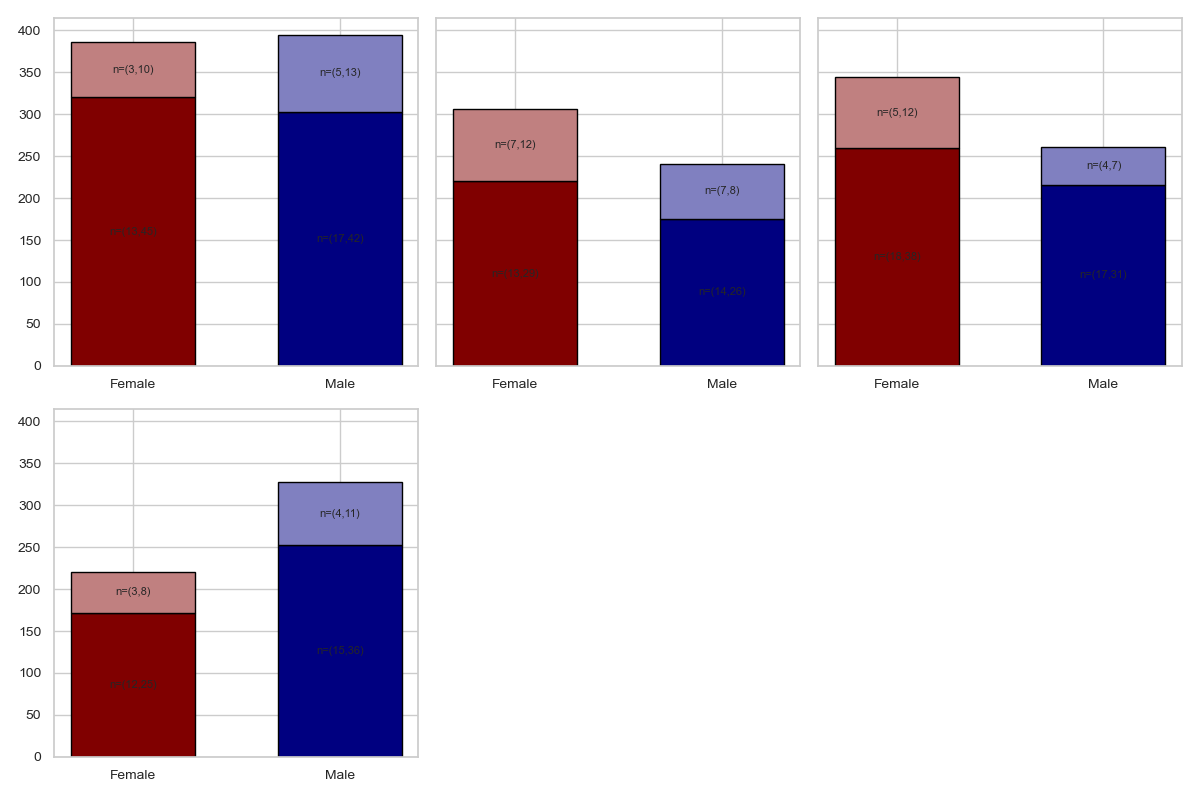

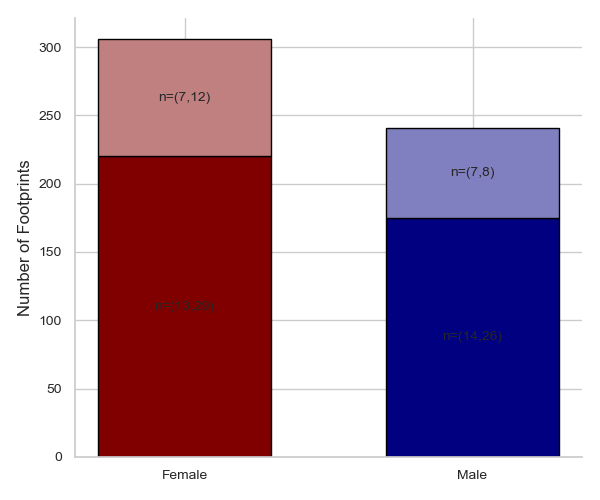

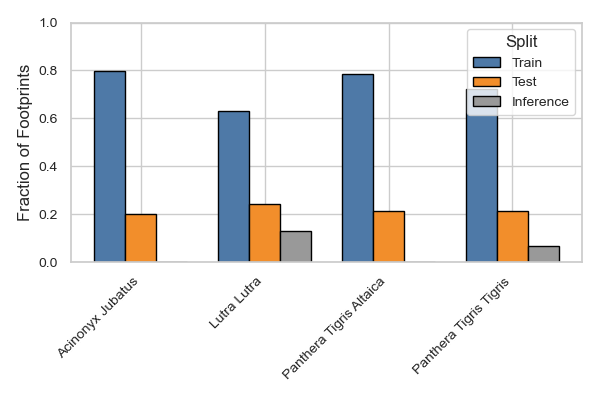

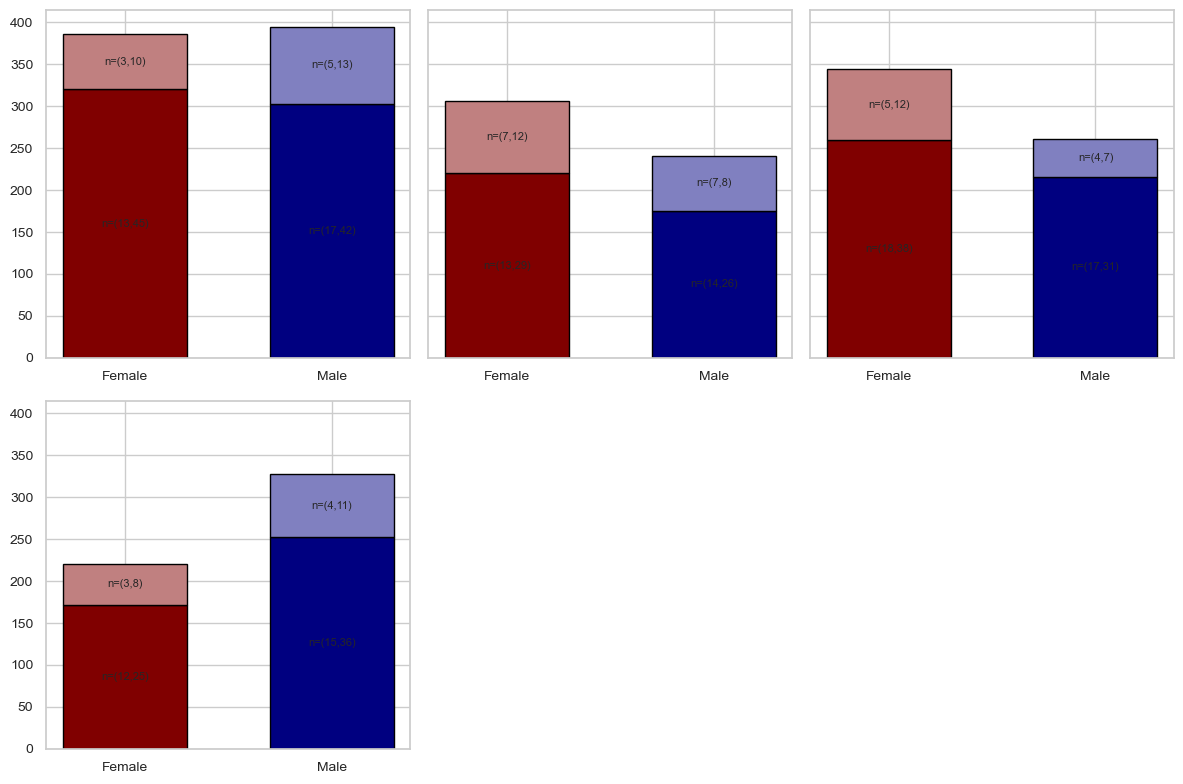

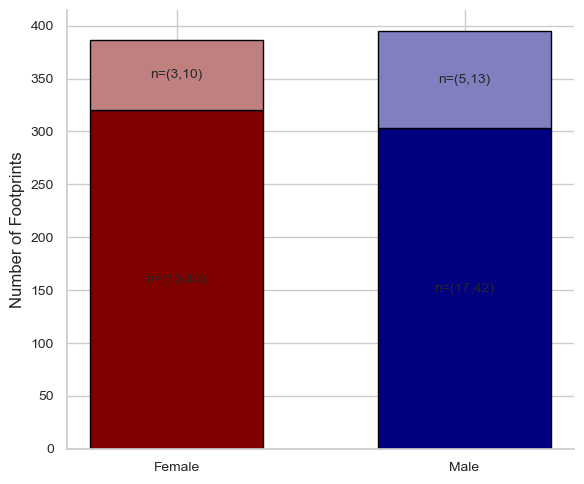

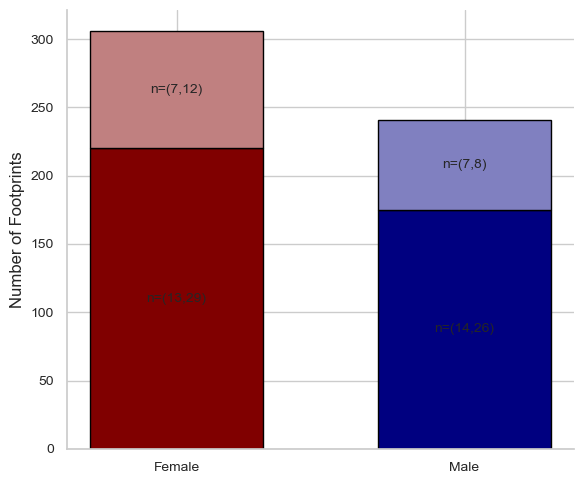

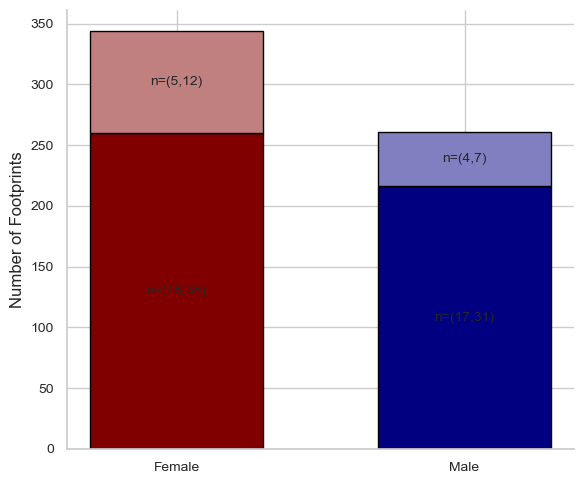

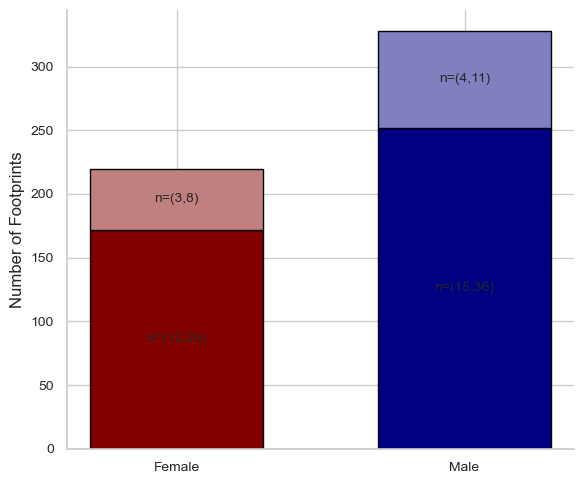

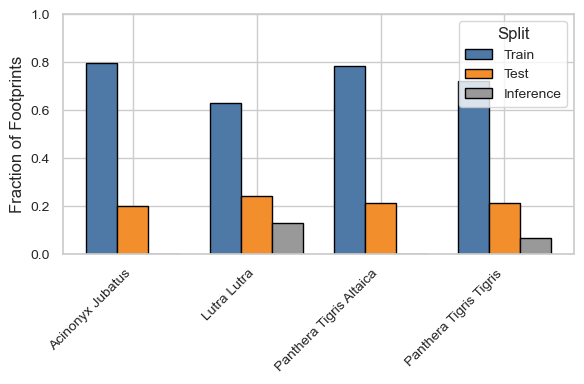

In [4]:
from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from IPython.display import Image, display

SplitWrapper().split_all(reuse_splits=True)
run_summary(SPLITS_DIR, EXP_DIR/'split_summary.csv', EXP_DIR/'split_fig')
display(Image(filename=EXP_DIR/'split_fig/summary_all.png'))
display(Image(filename=EXP_DIR/'split_fig/lutra_lutra_summary.png'))
display(Image(filename=EXP_DIR/'split_fig/split_proportions.png'))



Data Exploration (This step is performed exclusively on the otter data to keep the number of plots manageable.)
With over two hundred measurements extracted from just 11 unique landmarks, we anticipate high correlation among features. Previous FIT publications have shown that using many measurements aids individual identification. However, when the number of measurements far exceeds the number of landmarks, strong correlations between individual measurements emerge.
1.	A correlation matrix (Distances, Angles, Areas) is visualized (see “Correlation Matrix for Eurasian Otters”).
2.	We examine the top four univariate features with the highest separation power for the targets “sex” and “individual_id” on the full otter dataset.
3.	We generate two supervised UMAP embeddings—for “sex” and for “individual_id”—using fivefold cross-validation. Note that these embeddings are for visualization only; all modeling steps described later adhere to a stricter split regime.


In [5]:
#only for data exploration the cleaned otter data is used
otter_df = pd.read_parquet(CLEANED_DIR / 'Eurasian_Otter.parquet')
otter_df = otter_df.dropna(subset=['sex', 'individual_id'])
otter_df = otter_df[~otter_df['sex'].astype(str).str.lower().eq('na')]
otter_df = otter_df[~otter_df['individual_id'].astype(str).str.lower().eq('na')]
fig_path = plot_feature_correlation_matrix(otter_df, EXP_DIR)
fig_path

[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.


WindowsPath('C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/experiments/fit_start_to_finish/feature_corr_matrix_2x2.png')

In [6]:
from FIT_python.Visualisations.plot_style import map_sex
otter_df['sex_mapped'] = map_sex(otter_df['sex'])
top_sex = select_top_features(otter_df, 'sex', k=4)
plot_sex_boxplots(otter_df, top_sex, EXP_DIR, 'sex_boxplots.png')

[CAPTION] Boxplots of features ['dist10_14', 'dist3_10', 'dist9_14', 'dist10_13'] by sex (Female, Male).


WindowsPath('C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/experiments/fit_start_to_finish/sex_boxplots.png')

In [7]:
top_ind = select_top_features(otter_df, 'individual_id', k=4)
plot_individual_boxplots(otter_df, top_ind, EXP_DIR, 'individual_boxplots.png')


[CAPTION] Boxplots of ['dist12_14', 'dist13_15', 't2_3_5', 't12_13_15'] grouped by individual


WindowsPath('C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/experiments/fit_start_to_finish/individual_boxplots.png')

In [8]:
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
print("Features in otter_df:", otter_df.columns.tolist())
print(otter_df["dataorigin"].unique())
otter_df = otter_df[otter_df['dataorigin'].isin(['Vetrecova et al', 'Own Data Collection'])]
features = get_feature_cols(otter_df)
print("Numeric features in otter_df:", features)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)
dr = DimensionalityReducerTransformer(method='umap', supervised=True)
emb = dr.fit_transform(X, otter_df['individual_id'])
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=map_sex(otter_df['sex'])
)


Features in otter_df: ['id', 'species', 'individual_id', 'date', 'location', 'dataorigin', 'substrate', 'sex', 'trail', 'dist1_2', 'dist1_3', 'dist1_4', 'dist1_5', 'dist1_6', 'dist1_7', 'dist1_8', 'dist1_9', 'dist1_10', 'dist1_11', 'dist1_12', 'dist1_13', 'dist1_14', 'dist1_15', 'dist1_16', 'dist1_17', 'dist2_3', 'dist2_4', 'dist2_5', 'dist2_6', 'dist2_7', 'dist2_8', 'dist2_9', 'dist2_10', 'dist2_11', 'dist2_12', 'dist2_13', 'dist2_14', 'dist2_15', 'dist2_16', 'dist2_17', 'dist3_4', 'dist3_5', 'dist3_6', 'dist3_7', 'dist3_8', 'dist3_9', 'dist3_10', 'dist3_11', 'dist3_12', 'dist3_13', 'dist3_14', 'dist3_15', 'dist3_16', 'dist3_17', 'dist4_5', 'dist4_6', 'dist4_7', 'dist4_8', 'dist4_9', 'dist4_10', 'dist4_11', 'dist4_12', 'dist4_13', 'dist4_14', 'dist4_15', 'dist4_16', 'dist4_17', 'dist5_6', 'dist5_7', 'dist5_8', 'dist5_9', 'dist5_10', 'dist5_11', 'dist5_12', 'dist5_13', 'dist5_14', 'dist5_15', 'dist5_16', 'dist5_17', 'dist6_7', 'dist6_8', 'dist6_9', 'dist6_10', 'dist6_11', 'dist6_12', '

c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [9]:
marker_map = make_marker_map(emb_df['individual_id'].unique())
plot_umap_by_individual(emb_df, marker_map, EXP_DIR, 'umap_individual_symbols.png', use_sex_colors=True, legend=False)


[CAPTION] UMAP1/UMAP2 UMAP by individual


C:\Users\Frede\AppData\Local\Temp\ipykernel_27960\2219730940.py:2: DeprecationWarning: `plot_umap_by_individual` now expects the figure directory as the second argument. Pass custom markers via the `marker_map` keyword.
  plot_umap_by_individual(emb_df, marker_map, EXP_DIR, 'umap_individual_symbols.png', use_sex_colors=True, legend=False)


WindowsPath('C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/experiments/fit_start_to_finish/umap_individual_symbols.png')

Baseline Model: Sex Classification Across Species
We employed a stepwise Linear Discriminant Analysis (LDA) classifier, a method widely used in ecological and conservation research due to its interpretability, robustness on small datasets, and successful application in similar contexts—such as a pilot study on Eurasian otters by Mercier (2004) [Mercier, 2004; Alibhai et al., 2017; Tucker et al., 2024].
Variable selection followed a stepwise procedure:
•	Forward selection: Variables with a high F-ratio and an associated p-value below 0.05 were included in the model.
•	Backward elimination: Variables with p-values above 0.05 were iteratively removed.
These steps were repeated until no further variables met the respective inclusion or exclusion criteria.
To evaluate the model's generalizability, five-fold cross-validation was performed using the validation folds of the training set generated during the initial data split. We trained with an optimization goal of a high F1 value to achieve good classification rates in both classes
The resulting LDA classifier assigned each prediction a confidence score ranging from 0 to 1, used to assess certainty. Confidence levels were defined as follows:
•	High Confidence: Confidence score > 0.9
•	Moderate Confidence: Confidence score > 0.7 and ≤ 0.9
•	Low Confidence: Confidence score ≤ 0.

Evaluation Metrics for Sex Classification
The performance of the sex classification model was assessed using multiple datasets: (1) the validation folds derived from the training set, consisting of footprints from known captive otters; (2) a test set featuring new individuals from captive environments (across both sexes) with substrate types of mud and sand; and (3) wild otters with sex confirmed through DNA analysis.
Model evaluations were conducted at two levels: the individual footprint level and the trail-level aggregation. For the trail-level assessment, predictions from individual footprints were combined via majority voting. Confidence categories for aggregated predictions adhered to the same thresholds defined for individual footprints.
Baseline models were constructed using the full multi-species dataset. A summary table was generated to compare standard machine learning metrics, including Accuracy, Balanced Accuracy, Recall, Precision, and F1 Score. In addition to standard performance metrics, two custom Python functions were implemented to provide further insight into model behavior at the individual level:
•	The individual_accuracies() function calculates average prediction accuracy for female and male otters separately, based on true labels. By computing the mean footprint-level accuracy per individual and aggregating separately across sexes, this metric allows for the comparison of classification performance between groups. The balanced accuracy is reported as the average of female and male individual accuracies.
•	The individual_majority_stats() function assesses classification success at the individual level by counting the number of individuals for whom the model correctly predicted the majority of their footprints. Specifically, if more than 50% of an individual's footprints were correctly predicted, the individual is considered correctly classified. This function returns the count of correctly and incorrectly predicted individuals, along with the proportion of correct classifications.
These individual-level metrics complement footprint-level and trail-level evaluations by providing a more nuanced understanding of model consistency and reliability across subjects.



In [10]:
#from here on use only Train sets for all further steps!!!

In [11]:
from FIT_python.pipeline_sex.sex_config import run_otter_search_sex, run_other_species_search
from FIT_python.pipeline_sex import collect_best_metrics
from FIT_python.config import RESULTS_DATA_DIR

# BayesSearchCV ausführen (legt automatisch species-bezogene Unterordner an)
run_otter_search_sex()       # Otter
run_other_species_search()   # alle übrigen Spezies

# Zusammenfassung der besten Modelle für Auswertung und Visualisierung
summary_df = collect_best_metrics(RESULTS_DATA_DIR)

eurasian_otter BS-CV:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

Fitting 3 folds for each of 1 candidates, totalling 3 fits


UnboundLocalError: cannot access local variable 'reducer' where it is not associated with a value

In [ ]:
from FIT_python.pipeline_sex import (
    run_simple_baseline_all_species,
    plot_accuracy_comparison,
    plot_majority_comparison,
)
from IPython.display import Image, display

summary_df = run_simple_baseline_all_species(EXP_DIR, n_jobs=-1, reuse_results=True, max_features=3)
summary_df

acc_fig = plot_accuracy_comparison(summary_df, EXP_DIR)
maj_fig = plot_majority_comparison(summary_df, EXP_DIR)
display(Image(filename=acc_fig))
display(Image(filename=maj_fig))


In [ ]:

from FIT_python.pipeline_individual_id import (
    run_simple_baseline_all_species,
    collect_id_metrics,
    plot_bcr_comparison,
)
from IPython.display import Image, display
ID_EXP = EXP_DIR / 'fold_cv'    # or any directory for the fold-based results
best_k = 18

BENCH_CUTOFFS = {
    'amur_tiger': {'k': 18, 'ward': 1.95},
    'cheetah': {'k': 18, 'ward': 1.90},
    'giant_panda': {'k': 12, 'ward': 1.50},
    'mountain_lion': {'k': 18, 'ward': 1.90},
    'white_rhino': {'k': 12, 'ward': 1.95},
}

run_simple_baseline_all_species(ID_EXP, best_k, BENCH_CUTOFFS, subsample=True,
                                reuse_summary=False, n_jobs=-1)

metrics_df = collect_id_metrics(ID_EXP)
metrics_df

bcr_fig = plot_bcr_comparison(metrics_df, ID_EXP / 'fig')
display(Image(filename=bcr_fig))


In [ ]:
# %% Vergleich: Elliptic vs. Isotropic vs. Pooled Isotropic vs. Distance‑Classifier mit Feature‑Selection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import PredefinedSplit
from scipy.stats import chi2
from ast import literal_eval

# --- parse_list Utility ---
def parse_list(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, dtype=float)
    if isinstance(val, str):
        try:
            return np.asarray(literal_eval(val), dtype=float)
        except Exception:
            return np.empty(0, float)
    return np.empty(0, float)

# --- Confusion‑Matrix als DataFrame ---
def compute_confusion_df(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[1,0])
    return pd.DataFrame(
        cm,
        index=["true_same","true_diff"],
        columns=["pred_same","pred_diff"]
    )

# --- Gepoolte isotrope Überlappung ---
def compute_overlap_pooled(row, p: float) -> bool:
    xa = parse_list(row["coords_a_x"]); ya = parse_list(row["coords_a_y"])
    xb = parse_list(row["coords_b_x"]); yb = parse_list(row["coords_b_y"])
    if xa.size<2 or xb.size<2 or xa.size!=ya.size or xb.size!=yb.size:
        return False
    pts_a = np.column_stack([xa, ya])
    pts_b = np.column_stack([xb, yb])
    mu_a, mu_b = pts_a.mean(0), pts_b.mean(0)
    da = np.linalg.norm(pts_a - mu_a, axis=1)
    db = np.linalg.norm(pts_b - mu_b, axis=1)
    σp = np.sqrt((da.std(ddof=1)**2 + db.std(ddof=1)**2) / 2)
    chi = np.sqrt(chi2.ppf(p, df=2))
    return np.linalg.norm(mu_a - mu_b) <= 2 * chi * σp

# --- aus Deiner Evaluation ---
from FIT_python.pipeline_individual_id.evaluation import (
    compute_overlap_jsl_style,            # elliptisch
    compute_overlap_jsl_style_isotropic  # separate isotrope Kreise
)

# --- Setup ---
BASE_DIR = Path("results/experiments/fit_start_to_finish/fold_cv")
P_VALUES = np.linspace(0.1, 1.0, 50)
methods = [
    ("elliptic",   compute_overlap_jsl_style),
    ("isotropic",  compute_overlap_jsl_style_isotropic),
    ("pooled_iso", compute_overlap_pooled),
]

for species_dir in sorted(BASE_DIR.iterdir()):
    if not species_dir.is_dir(): 
        continue
    csv_fp = species_dir / "all_folds.csv"
    if not csv_fp.exists():
        continue

    df = pd.read_csv(csv_fp)
    # teste, dass es eine Spalte "fold" gibt
    folds = df["fold"].astype(int).to_numpy()

    # 1) Für jede Methode bestes p via Fold‑CV
    results = {}
    for name, func in methods:
        best_p, best_acc = None, -1.0
        for p in P_VALUES:
            accs = []
            for f in np.unique(folds):
                sub = df[folds == f]
                preds = sub.apply(func, axis=1, p=p)
                accs.append(balanced_accuracy_score(sub["same_individual"], preds))
            macc = np.mean(accs)
            if macc > best_acc:
                best_acc, best_p = macc, p

        # final Vorhersage + Confusion
        df[f"pred_{name}"] = df.apply(func, axis=1, p=best_p)
        cm_df = compute_confusion_df(
            df["same_individual"].map({True:1, False:0}),
            df[f"pred_{name}"].map({True:1, False:0})
        )
        results[name] = (best_p, best_acc, cm_df)

    # 2) Distance‑Classifier mit Regularisierung & Feature‑Selection
    dist_cols = [c for c in df.columns if c.startswith(("dist_","mean_","median_"))]
    X = df[dist_cols].to_numpy()
    y = df["same_individual"].map({True:1, False:0}).to_numpy()

    # PredefinedSplit für LogisticRegressionCV
    ps = PredefinedSplit(test_fold=folds)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    clf = LogisticRegressionCV(
        Cs=10,
        cv=ps,
        penalty='l1',
        solver='liblinear',
        scoring='balanced_accuracy',
        max_iter=1000,
        refit=True
    )
    clf.fit(X_scaled, y)

    y_pred = clf.predict(X_scaled)
    acc_clf = balanced_accuracy_score(y, y_pred)
    cm_clf = compute_confusion_df(y, y_pred)
    results["dist_clf"] = (None, acc_clf, cm_clf)

    # Top‑10 Features nach |Koeffizient|
    coefs = pd.Series(
        np.abs(clf.coef_).ravel(),
        index=dist_cols
    ).sort_values(ascending=False)
    top_feats = coefs.head(10)

    # 3) Plot: 1×4 Confusion‑Matrices
    fig, axes = plt.subplots(1, 4, figsize=(18,4))
    for ax, (name, (p_best, acc_best, cm_df)) in zip(axes, results.items()):
        cm_norm = cm_df.divide(cm_df.sum(axis=1), axis=0)
        sns.heatmap(
            cm_norm, annot=cm_df, fmt="d", cmap="Blues",
            xticklabels=cm_df.columns, yticklabels=cm_df.index,
            cbar=False, ax=ax
        )
        title = f"{species_dir.name}\n{name}"
        if p_best is not None:
            title += f"\np={p_best:.2f}"
        title += f"\nacc={acc_best:.2f}"
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()

    # 4) Top‑10 Features anzeigen
    print(f"\nTop‑10 Features distance‑classifier ({species_dir.name}):")
    display(top_feats.to_frame("importance"))


In [ ]:
from pathlib import Path
import pandas as pd

from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import generate_pairwise_comparisons_from_df
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline

RESULTS_DIR = Path("results/eval_pairs")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for sp_dir in sorted(Path("data/splits").iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    print(f"Processing {species} ...")

    df_train = pd.read_parquet(sp_dir / "train.parquet")
    df_test = pd.read_parquet(sp_dir / "test.parquet")
    feature_cols = get_feature_cols(df_train)

    # Build pairwise comparisons from the test set
    comps, _ = generate_pairwise_comparisons_from_df(
        df_test, strategy="select", evaluation=True, subsample=True
    )

    # Run baseline with the train set as RCV
    res_df = DistanceBaseline.run(
        train_df=df_train,
        val_comparisons=comps,
        val_df=df_test,
        feature_cols=feature_cols,
        reducers=["lda"],
        selection_method="forward",
        n_components=2,
        n_jobs=-1,
    )

    out_path = RESULTS_DIR / f"{species}_pairs.csv"
    res_df.to_csv(out_path, index=False)
    print(f"Saved pairwise results to {out_path}")


In [ ]:
# Train per-species overlap thresholds and a distance classifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import PredefinedSplit
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2
from ast import literal_eval

# --- utilities ---------------------------------------------------------------
def parse_list(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, dtype=float)
    if isinstance(val, str):
        try:
            return np.asarray(literal_eval(val), dtype=float)
        except Exception:
            return np.empty(0, float)
    return np.empty(0, float)

def compute_confusion_df(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    return pd.DataFrame(cm,
        index=["true_same", "true_diff"],
        columns=["pred_same", "pred_diff"]
    )

def compute_overlap_pooled(row, p):
    xa = parse_list(row["coords_a_x"]); ya = parse_list(row["coords_a_y"])
    xb = parse_list(row["coords_b_x"]); yb = parse_list(row["coords_b_y"])
    if len(xa) < 2 or len(xb) < 2 or len(xa) != len(ya) or len(xb) != len(yb):
        return False
    pts_a = np.column_stack([xa, ya])
    pts_b = np.column_stack([xb, yb])
    mu_a, mu_b = pts_a.mean(0), pts_b.mean(0)
    da = np.linalg.norm(pts_a - mu_a, axis=1)
    db = np.linalg.norm(pts_b - mu_b, axis=1)
    sigma_p = np.sqrt((da.std(ddof=1) ** 2 + db.std(ddof=1) ** 2) / 2)
    chi = np.sqrt(chi2.ppf(p, df=2))
    return np.linalg.norm(mu_a - mu_b) <= 2 * chi * sigma_p

# --- overlap functions from the package -------------------------------------
from FIT_python.pipeline_individual_id.evaluation import (
    compute_overlap_jsl_style,
    compute_overlap_jsl_style_isotropic,
    compute_overlap_rhombus,
)

# ----------------------------------------------------------------------------- 
BASE_DIR = Path("results/experiments/fit_start_to_finish/fold_cv")
P_VALUES = np.linspace(0.1, 1.0, 50)
methods = [
    ("Elliptic",   compute_overlap_jsl_style),
    ("Isotropic",  compute_overlap_jsl_style_isotropic),
    ("PooledIso",  compute_overlap_pooled),
    ("Rhombus",    compute_overlap_rhombus),
]

best_p = {}
trained_clfs = {}

for species_dir in sorted(BASE_DIR.iterdir()):
    if not species_dir.is_dir():
        continue
    csv_fp = species_dir / "all_folds.csv"
    if not csv_fp.exists():
        continue

    df = pd.read_csv(csv_fp)
    folds = df["fold"].astype(int).to_numpy()

    results = {}
    for name, func in methods:
        p_best, acc_best = None, -1.0
        for p in P_VALUES:
            accs = []
            for f in np.unique(folds):
                sub = df[folds == f]
                preds = sub.apply(func, axis=1, p=p)
                accs.append(balanced_accuracy_score(sub["same_individual"], preds))
            macc = np.mean(accs)
            if macc > acc_best:
                acc_best, p_best = macc, p
        df[f"pred_{name}"] = df.apply(func, axis=1, p=p_best)
        cm_df = compute_confusion_df(
            df["same_individual"].map({True: 1, False: 0}),
            df[f"pred_{name}"].map({True: 1, False: 0})
        )
        results[name] = (p_best, acc_best, cm_df)
    best_p[species_dir.name] = {n: bp for n, (bp, _, _) in results.items()}

    # --- logistic regression distance classifier -----------------------------
    dist_cols = [c for c in df.columns if c.startswith(("dist_", "mean_", "median_"))]
    X = df[dist_cols].to_numpy()
    y = df["same_individual"].map({True: 1, False: 0}).to_numpy()
    ps = PredefinedSplit(test_fold=folds)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LogisticRegressionCV(
        Cs=10,
        cv=ps,
        penalty="l1",
        solver="liblinear",
        scoring="balanced_accuracy",
        max_iter=1000,
        refit=True,
    )
    clf.fit(X_scaled, y)
    trained_clfs[species_dir.name] = (scaler, clf)

    y_pred = clf.predict(X_scaled)
    acc_clf = balanced_accuracy_score(y, y_pred)
    cm_clf = compute_confusion_df(y, y_pred)
    results["DistClf"] = (None, acc_clf, cm_clf)

    # --- visualise confusion matrices ---------------------------------------
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
    for ax, (name, (p_best, acc_best, cm_df)) in zip(axes, results.items()):
        cm_norm = cm_df.divide(cm_df.sum(axis=1), axis=0)
        sns.heatmap(cm_norm, annot=cm_df, fmt="d", cmap="Blues",
                    xticklabels=cm_df.columns, yticklabels=cm_df.index,
                    cbar=False, ax=ax)
        title = f"{species_dir.name}\n{name}"
        if p_best is not None:
            title += f"\np={p_best:.2f}"
        title += f"\nacc={acc_best:.2f}"
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

    # --- inspect top features of distance classifier ------------------------
    coefs = pd.Series(np.abs(clf.coef_).ravel(), index=dist_cols).sort_values(ascending=False)
    display(coefs.head(10).to_frame("importance"))


In [ ]:
# %% Evaluation auf Test‐Sets: Overlap‐Methoden + Distance‐Classifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix
from ast import literal_eval
from scipy.stats import chi2

# --- parse_list Utility ---
def parse_list(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, dtype=float)
    if isinstance(val, str):
        try:
            return np.asarray(literal_eval(val), dtype=float)
        except Exception:
            return np.empty(0, float)
    return np.empty(0, float)

# --- Confusion‐Matrix als DataFrame ---
def compute_confusion_df(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    return pd.DataFrame(cm,
        index=["true_same", "true_diff"],
        columns=["pred_same", "pred_diff"]
    )

# --- Gepoolte isotrope Überlappung ---
def compute_overlap_pooled(row, p):
    xa = parse_list(row["coords_a_x"]); ya = parse_list(row["coords_a_y"])
    xb = parse_list(row["coords_b_x"]); yb = parse_list(row["coords_b_y"])
    if xa.size<2 or xb.size<2 or xa.size!=ya.size or xb.size!=yb.size:
        return False
    pts_a = np.column_stack([xa, ya])
    pts_b = np.column_stack([xb, yb])
    mu_a, mu_b = pts_a.mean(0), pts_b.mean(0)
    da = np.linalg.norm(pts_a - mu_a, axis=1)
    db = np.linalg.norm(pts_b - mu_b, axis=1)
    sigma_p = np.sqrt((da.std(ddof=1)**2 + db.std(ddof=1)**2)/2)
    chi = np.sqrt(chi2.ppf(p, df=2))
    return np.linalg.norm(mu_a - mu_b) <= 2 * chi * sigma_p

# --- Importiere Overlap‐Funktionen & gelernte Parameter ---
from FIT_python.pipeline_individual_id.evaluation import (
    compute_overlap_jsl_style,          # elliptisch
    compute_overlap_jsl_style_isotropic,# separate isotrope Kreise
    compute_overlap_rhombus             # Rhombus‐Methode, falls vorhanden
)
# best_p und trained_clfs sollten im Workspace vorhanden sein:
#   best_p: Dict[species_name, {method_name: best_p_value, …}, …]
#   trained_clfs: Dict[species_name, (scaler, clf), …]

methods = [
    ("Elliptic",   compute_overlap_jsl_style),
    ("Isotropic",  compute_overlap_jsl_style_isotropic),
    ("PooledIso",  compute_overlap_pooled),
    ("Rhombus",    compute_overlap_rhombus),
]

# --- Loop über Test‐Dateien ---
for csv_fp in Path("results/eval_pairs").glob("*_pairs.csv"):
    species = csv_fp.stem.replace("_pairs", "")
    if species not in best_p:
        continue

    print(f"\n=== Testset: {species} ===")
    df = pd.read_csv(csv_fp)

    # wandle Truth‐Spalte um
    y_true_full = df["same_individual"].map({True:1, False:0})

    # Dist‐Classifier laden, falls vorhanden
    has_clf = species in trained_clfs
    if has_clf:
        scaler, clf = trained_clfs[species]

    # Plot‐Grid vorbereiten
    total = len(methods) + (1 if has_clf else 0)
    fig, axes = plt.subplots(1, total, figsize=(4*total, 4))

    # 1) Overlap‐Methoden
    for ax, (name, func) in zip(axes, methods):
        p_val = best_p[species].get(name)
        if p_val is None:
            ax.axis("off"); continue

        col = f"pred_{name}"
        if name == "Elliptic":
            # vectorisierte Variante
            df[col] = func(df, p=p_val)
        else:
            df[col] = df.apply(func, axis=1, p=p_val)

        mask = df[col].notna()
        dropped = len(df) - mask.sum()
        if dropped>0:
            print(f"  {name}: droppe {dropped} Zeilen mit NaN in {col}")

        y_true = y_true_full[mask]
        y_pred = df.loc[mask, col].map({True:1, False:0})

        cm = confusion_matrix(y_true, y_pred, labels=[1,0])
        cm_df = pd.DataFrame(cm, index=["true_same","true_diff"], columns=["pred_same","pred_diff"])
        cm_norm = cm_df.divide(cm_df.sum(axis=1), axis=0)

        sns.heatmap(cm_norm, annot=cm_df, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(f"{name}\np={p_val:.2f}")
        ax.set_xlabel("Pred")
        ax.set_ylabel("True")

    # 2) Distance‐Classifier (falls vorhanden)
    if has_clf:
        ax = axes[-1]
        # Distanz‐Features extrahieren
        dist_cols = [c for c in df.columns if c.startswith(("dist_","mean_","median_"))]
        X = df[dist_cols].to_numpy()
        # NaNs entfernen
        mask = ~np.isnan(X).any(axis=1)
        dropped = len(X) - mask.sum()
        if dropped>0:
            print(f"  DistClf: droppe {dropped} Zeilen mit NaN in Dist‐Features")
        Xm = scaler.transform(X[mask])
        y_pred = clf.predict(Xm)
        y_true = y_true_full[mask]

        cm = confusion_matrix(y_true, y_pred, labels=[1,0])
        cm_df = pd.DataFrame(cm, index=["true_same","true_diff"], columns=["pred_same","pred_diff"])
        cm_norm = cm_df.divide(cm_df.sum(axis=1), axis=0)

        sns.heatmap(cm_norm, annot=cm_df, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title("DistClf")
        ax.set_xlabel("Pred")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()


In [ ]:
# %% Vergleich: Elliptic, Isotropic & Pooled Isotropic – je ein 2×2‐Grid pro Methode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ast import literal_eval
from scipy.stats import chi2
from sklearn.metrics import balanced_accuracy_score
from matplotlib.patches import Ellipse

# --- parse_list Utility ---
def parse_list(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, dtype=float)
    if isinstance(val, str):
        try:
            return np.asarray(literal_eval(val), dtype=float)
        except Exception:
            return np.empty(0, float)
    return np.empty(0, float)

# --- Gepoolte isotrope Überlappung ---
def compute_overlap_pooled(row, p: float) -> bool:
    xa = parse_list(row["coords_a_x"]); ya = parse_list(row["coords_a_y"])
    xb = parse_list(row["coords_b_x"]); yb = parse_list(row["coords_b_y"])
    if xa.size<2 or xb.size<2 or xa.size!=ya.size or xb.size!=yb.size:
        return False
    pts_a, pts_b = np.column_stack([xa,ya]), np.column_stack([xb,yb])
    mu_a, mu_b = pts_a.mean(0), pts_b.mean(0)
    da = np.linalg.norm(pts_a - mu_a, axis=1)
    db = np.linalg.norm(pts_b - mu_b, axis=1)
    σp = np.sqrt((da.std(ddof=1)**2 + db.std(ddof=1)**2)/2)
    chi = np.sqrt(chi2.ppf(p, df=2))
    return np.linalg.norm(mu_a - mu_b) <= 2 * chi * σp

# --- aus Deiner Evaluation ---
from FIT_python.pipeline_individual_id.evaluation import (
    compute_overlap_jsl_style,            # elliptisch
    compute_overlap_jsl_style_isotropic  # getrennte isotrope Kreise
)

# --- Ellipse‐Parameter helper ---
def cov_ellipse_params(cov: np.ndarray, p: float):
    χ = chi2.ppf(p, df=2)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    w, h = 2*np.sqrt(vals * χ)
    ang = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    return w, h, ang

# --- Setup ---
BASE_DIR = Path("results/experiments/fit_start_to_finish/fold_cv")
P_VALUES = np.linspace(0.1, 1.0, 50)
cats = {"TP":(True,True),"FP":(False,True),"FN":(True,False),"TN":(False,False)}
methods = [
    ("Elliptic",   compute_overlap_jsl_style),
    ("Isotropic",  compute_overlap_jsl_style_isotropic),
    ("PooledIso",  compute_overlap_pooled),
]

for species_dir in sorted(BASE_DIR.iterdir()):
    if not species_dir.is_dir(): 
        continue
    csv_fp = species_dir / "all_folds.csv"
    if not csv_fp.exists(): 
        continue

    df = pd.read_csv(csv_fp)
    folds = sorted(df["fold"].unique())

    # 1) bestes p per Methode via Fold‑CV
    best = {}
    for name, func in methods:
        bp, bs = None, -1.0
        for p in P_VALUES:
            accs = []
            for f in folds:
                sub = df[df["fold"]==f]
                preds = sub.apply(func, axis=1, p=p)
                accs.append(balanced_accuracy_score(sub["same_individual"], preds))
            macc = np.mean(accs)
            if macc > bs:
                bs, bp = macc, p
        best[name] = (bp, bs)

    # 2) pick one example per TP/FP/FN/TN from elliptic method
    df["pred_ell"] = df.apply(compute_overlap_jsl_style, axis=1, p=best["Elliptic"][0])
    df["_gt"] = df["same_individual"].astype(bool)
    df["_pe"] = df["pred_ell"].astype(bool)
    examples = {}
    for k,(gt,pr) in cats.items():
        sel = df[(df["_gt"]==gt)&(df["_pe"]==pr)]
        if not sel.empty:
            examples[k] = sel.iloc[0]

    # 3) compute global plot limits
    all_x, all_y = [], []
    for row in examples.values():
        for pre in ("a","b","r"):
            all_x += list(parse_list(row[f"coords_{pre}_x"]))
            all_y += list(parse_list(row[f"coords_{pre}_y"]))
    xmin,xmax = min(all_x),max(all_x)
    ymin,ymax = min(all_y),max(all_y)
    dx,dy = (xmax-xmin)*0.05,(ymax-ymin)*0.05

    # 4) for each method, draw a separate 2×2 grid
    for name, func in methods:
        p_best,_ = best[name]
        fig, axes = plt.subplots(2,2, figsize=(6,6))
        fig.suptitle(f"{species_dir.name} — {name} (p={p_best:.2f}, acc={best[name][1]:.2f})", y=1.02)
        for ax, (k,(gt,pr)) in zip(axes.flat, cats.items()):
            row = examples.get(k)
            if row is None:
                ax.set_title(f"{k}\n(no example)")
                ax.axis("off")
                continue

            xa,ya = parse_list(row["coords_a_x"]), parse_list(row["coords_a_y"])
            xb,yb = parse_list(row["coords_b_x"]), parse_list(row["coords_b_y"])
            xr,yr = parse_list(row["coords_r_x"]), parse_list(row["coords_r_y"])
            ax.scatter(xa,ya, c="blue",   s=20)
            ax.scatter(xb,yb, c="orange", s=20)
            ax.scatter(xr,yr, c="lightgray", s=10)

            mu_a = np.column_stack([xa,ya]).mean(0)
            mu_b = np.column_stack([xb,yb]).mean(0)

            if name == "Elliptic":
                cov_a = np.cov(np.column_stack([xa,ya]), rowvar=False)
                cov_b = np.cov(np.column_stack([xb,yb]), rowvar=False)
                w_a,h_a,ang_a = cov_ellipse_params(cov_a, p_best)
                w_b,h_b,ang_b = cov_ellipse_params(cov_b, p_best)
                ax.add_patch(Ellipse(mu_a, w_a, h_a, angle=ang_a,
                                     edgecolor="blue", facecolor="none", lw=2))
                ax.add_patch(Ellipse(mu_b, w_b, h_b, angle=ang_b,
                                     edgecolor="orange", facecolor="none", lw=2))
            elif name == "Isotropic":
                da = np.linalg.norm(np.column_stack([xa,ya]) - mu_a, axis=1)
                db = np.linalg.norm(np.column_stack([xb,yb]) - mu_b, axis=1)
                χ = np.sqrt(chi2.ppf(p_best, df=2))
                ax.add_patch(plt.Circle(mu_a, χ*da.std(ddof=1), fill=False, edgecolor="blue",   lw=2))
                ax.add_patch(plt.Circle(mu_b, χ*db.std(ddof=1), fill=False, edgecolor="orange", lw=2))
            else:  # PooledIso
                da = np.linalg.norm(np.column_stack([xa,ya]) - mu_a, axis=1)
                db = np.linalg.norm(np.column_stack([xb,yb]) - mu_b, axis=1)
                σp = np.sqrt((da.std(ddof=1)**2 + db.std(ddof=1)**2)/2)
                χ = np.sqrt(chi2.ppf(p_best, df=2))
                ax.add_patch(plt.Circle(mu_a, χ*σp, fill=False, edgecolor="blue",   lw=2))
                ax.add_patch(plt.Circle(mu_b, χ*σp, fill=False, edgecolor="orange", lw=2))

            ax.set_aspect("equal")
            ax.set_xlim(xmin-dx, xmax+dx)
            ax.set_ylim(ymin-dy, ymax+dy)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(k)
        plt.tight_layout()
        plt.show()


In [ ]:
from FIT_python.Visualisations.display_mapping import (
    generate_display_mapping,
    apply_display_mapping,
)

mapping = generate_display_mapping(results_df)
results_df = apply_display_mapping(results_df, mapping)


Individual Identification Using FIT Models (baseline Models)
FIT models classify individual animals by comparing pairs of footprint trails using pairwise stepwise \gls{lda} (LDA) \cite{jewell2016spotting}. For each pairwise comparison, a dedicated LDA model is built to maximize separation between the two trails—treated as distinct groups—and a third group known as the \gls{rcv}. For each trail pair, the number of features used to calculate the canonical variates on the x- and y-axes is first reduced by selecting a predefined number of features based on their F-ratio. 
We used the above-described raw morphometric measurements as input variables.
For each trail, least-squares means (centroids) are calculated in canonical space, and 50% confidence-circles are plotted around them. Classification is based on whether these ellipses overlap: if they do, the trails are considered to originate from the same individual (“self”); if not, they are assumed to belong to different individuals (“non-self”) \cite{alibhai2008footprint,jewell2016spotting,li2018using}.
Because the spatial relationship between centroids is sensitive to the composition of the test set, two key modifications were implemented as originally proposed by \cite{jewell2001censusing}. First, comparisons are conducted on a strictly pairwise basis, isolating each pair of test trails. Second, the \gls{rcv}, derived from the centroids of the remaining known individuals, is used as a stable geometric anchor in canonical space. This stabilizes the positioning of the test-trail centroids and ensures consistent interpretation of their relative proximity.
To evaluate model performance, classification outcomes were recorded for each of the sequential holdout splits of the train set described above. The final FIT output includes a cluster dendrogram estimating the number of individuals present in the test set. Trails predicted to originate from the same individual were grouped based on hierarchical clustering of inter-trail distances.  
Details on the clustering procedure and its use for population-size estimation are provided in Section~\ref{sec:population_estimation}.

Balanced Classification Rate as Primary Metric
Previous FIT studies commonly reported overall classification accuracies derived from confusion matrices, categorizing positives as ‘self’ classifications (matching pairs) and negatives as ‘non-self’ classifications (mismatched pairs) (Alibhai et al., 2008; Jewell et al., 2016; Li et al., 2018; Alibhai et al., 2022). However, because non-self pairwise comparisons substantially outnumber self-comparisons, overall accuracy can be misleading. To address this imbalance, we adopted the Balanced Classification Rate (BCR), following Kistner et al. (2024).
The BCR equally weights the correct classification of matching (self) and non-matching (non-self) trail pairs, providing a balanced and robust evaluation of model performance. We evaluated BCR across the entire dataset and reported the average across all steps of the sequential holdout validation.
Population Size Estimation from Footprint Trails
To estimate the number of individuals represented in a given test set, we structured the pairwise discriminant distances between trails into a distance matrix. This matrix served as input for Ward’s hierarchical clustering algorithm, which groups trails by minimizing within-cluster variance. The resulting dendrogram visualizes these groupings and enables population size estimation.
We assessed estimation accuracy using the Dendrogram Error Rate (DER), defined as the absolute difference between the Predicted Number of Animals (PNA) and the True Number of Animals (TNA), divided by TNA:
DER = PNA − TNA / TNA
Lower DER values indicate better agreement between predicted and true numbers of individuals. For methodological background and metric validation, see Kistner et al. (2024).
The resulting dendrograms were visually inspected to verify the separation of clusters and support interpretability of population size estimates.
To further assess the accuracy of population size estimates across all validation folds, we plotted predicted versus true population sizes in a scatterplot. The identity line (y = x) represents the ideal case of perfect prediction. To quantify the deviation of each regression line from this ideal, we calculated the Concordance Correlation Coefficient (CCC) as proposed by Lin (1989).
The CCC evaluates both precision (Pearson correlation) and accuracy (closeness to the identity line) in a single metric. It is defined as:
ρc = [2ρ σx σy] / [σx2 + σy2 + (μx − μy)2] Where ρ is the Pearson correlation coefficient between predicted (y) and true (x) values, and μ, σ denote the respective means and standard deviations. A CCC of ρc = 1 indicates perfect agreement, while lower values reflect increasing divergence from the ideal y = x relationship.
This metric provides a robust basis for comparing different model hyperparameter configurations with respect to their population size estimation performance.
To determine the optimal dendrogram cutoff distance for population size estimation, we leveraged the known number of individuals in the training set. For each model, we identified the cutoff distance at which Ward's hierarchical clustering produced the target number of clusters (i.e., individuals). Based on the ranked list of cluster distances, we computed the statistical confidence that alternative cutoff distances would yield the same cluster count, using a t-statistic derived from the standard error of the distance distribution.
For each model, we then defined a confidence interval around the optimal cutoff: specifically, the range of distances associated with at least 25\% probability of yielding the correct number of clusters. This interval represents the uncertainty associated with the cutoff selection and is visualized in Figure~\ref{fig:cutoff_confidence_intervals}. These model-specific cutoffs and their confidence bounds were used for subsequent population size estimation in the test data.


Notebook block7 sequential training otter:   
Only  for Otters run sequential holdouts (default individual sequence, 10 itterations) @gtp make sure pairwise comparisons are always done for the validation set ad the rcv is always used from the corresponding train set (means new pairs and new rcv for every iteration and every ssequence of the pairwise comparison).  Use the Trail column for trails and don´t generate subsamples. 
For otter find the optimal number of variables in iterating through different k values between 12 and 20 variables.
Visualize a 2x2 plot matrixs mimicking a  confusion matrix. In each cell I want visual examples of the pairs and their confidence circle either overlapping or not for cases of pairs from the same and from different animals. You probably need to write helper for that.
Visualize confusion matrix for validation folds (don´t know how to best do this sinse different datasets differ in sizes quite abit. Might make sense just to sum all individual confusion matrixes of the sequential holdout validation fold to one confusion matrix??? open to suggestion @gtp)
For every number of k. Find the optimal cutoff value for using the results of the sequential holdouts.  Otters with the above-described approaches. Plot the regression line for the predicted number of individuals for this cutoff vs the line of true number of individuals (line im ursprung mit steigung 1) .
Run the model with the best parameter for otters (number of variables k, Wards cutoff distance) for all Folds of the training set and the testset
Visualize a dendrogram for each validation fold and the test set


In [ ]:
from FIT_python.pipeline_individual_id import (
    run_simple_baseline_otter,
    collect_id_metrics,
    plot_bcr_comparison,
)
from FIT_python.Visualisations.plots_utils import (
    plot_pair_examples,
    plot_dendrogram,
)
from FIT_python.pipeline_individual_id.population_estimation import optimal_cutoff
import pandas as pd
import numpy as np
from IPython.display import Image, display

ID_EXP = EXP_DIR / 'id_baseline'
k_values = range(12, 14)
best_k = run_simple_baseline_otter(ID_EXP, k_range=k_values, iterations=3)
best_k



In [ ]:
from FIT_python.pipeline_individual_id.sequential_holdout import (
    compute_global_cutoffs,
    evaluate_with_cutoff,
)

for k in k_values:
    result_dir = ID_EXP / 'otter' / f'k{k}'
    cutoffs = compute_global_cutoffs(result_dir / 'all_splits.csv')
    mean_cutoff = cutoffs['mean_cutoff']
    median_cutoff = cutoffs['median_cutoff']
    mean_low = cutoffs['mean_low']
    mean_high = cutoffs['mean_high']

    eval_mean = evaluate_with_cutoff(result_dir, cutoff=mean_cutoff)
    eval_median = evaluate_with_cutoff(result_dir, cutoff=median_cutoff)
    eval_low = evaluate_with_cutoff(result_dir, cutoff=mean_low)
    eval_high = evaluate_with_cutoff(result_dir, cutoff=mean_high)

    eval_mean.to_csv(result_dir / 'eval_mean.csv', index=False)
    eval_median.to_csv(result_dir / 'eval_median.csv', index=False)
    eval_low.to_csv(result_dir / 'eval_mean_low.csv', index=False)
    eval_high.to_csv(result_dir / 'eval_mean_high.csv', index=False)

eval_mean, eval_median, eval_low, eval_high


Notbookblock 8 benchmarking:
Run the model with the best parameter for otters (number of variables k, Wards cutoff distance) for all Folds of the training set and the testset
For all species not otter use these parameters in addition to forward selection and lda
Parameters for Benchmarkspecies:
________________________________________
Table: FIT Parameters by Species
Species	No. of Variables	Counter Probability	Ward’s Cut-off Distance
Amur Tiger	18	0.50	1.95
Panthera tigris altaica			
Cheetah	18	0.50	1.90
Acinonyx jubatus			
Giant Panda	12	0.50	1.50
Ailuropoda melanoleuca			
Mountain Lion	18	0.50	1.90
Puma concolor			
White Rhino	12	0.50	1.95
Ceratotherium simum			
________________________________________

make a summary table comparing  balanced classification rate for all species on the validation folds and the metrics of each test set). Use overlap jsl style for classification. Have a 50% likelihood for the circles that trails originate from either a same or different animal. (save results for every sequential holdout comparison and every iteration in an appropriate format so that this results database can be used in further analyses and visualization of the next block! For future blocks.


In [ ]:
from FIT_python.Visualisations.plots_utils import plot_pred_true_counts

n_train = otter_df['individual_id'].nunique()
scatter_fig = plot_pred_true_counts(
    {
        'mean': eval_mean,
        'median': eval_median,
        'mean_low': eval_low,
        'mean_high': eval_high,
    },
    result_dir / 'pred_vs_true_global.png',
    regression=True,
    n_train=n_train,
)
display(Image(filename=scatter_fig))


In [ ]:
split_dir = ID_EXP / 'otter' / f'k{best_k}'
for csv_fp in sorted(split_dir.glob('split_*.csv')):
    df_res = pd.read_csv(csv_fp)
    trails = sorted(set(df_res['trail_a_id']) | set(df_res['trail_b_id']))
    mapping = generate_display_mapping(df_res)
    dist = pd.DataFrame(np.nan, index=trails, columns=trails)
    dist = apply_display_mapping(dist, mapping)
    for a, b, d in zip(df_res['trail_a_id'], df_res['trail_b_id'], df_res['dist_euclidean']):
        try:
            val = float(d)
        except Exception:
            continue
        dist.at[a, b] = val
        dist.at[b, a] = val
    np.fill_diagonal(dist.values, 0.0)
    dist = dist.fillna(np.nanmax(dist.values))
    dend_fig = plot_dendrogram(
        dist,
        split_dir / f'{csv_fp.stem}_dendrogram.png',
        cutoff_low=mean_cutoff,
        cutoff_high=mean_high,
    )
    display(Image(filename=dend_fig))

In [ ]:
from FIT_python.pipeline_individual_id import (
    run_baseline_all_species,
    collect_id_metrics,
    plot_bcr_comparison,
)
from IPython.display import Image, display

BENCH_CUTOFFS = {
    'amur_tiger': {'k': 18, 'ward': 1.95},
    'cheetah': {'k': 18, 'ward': 1.90},
    'giant_panda': {'k': 12, 'ward': 1.50},
    'mountain_lion': {'k': 18, 'ward': 1.90},
    'white_rhino': {'k': 12, 'ward': 1.95},
}

run_baseline_all_species(ID_EXP, best_k, BENCH_CUTOFFS, reuse_summary=True, n_jobs=-1)
metrics_df = collect_id_metrics(ID_EXP)
metrics_df

bcr_fig = plot_bcr_comparison(metrics_df, ID_EXP / 'fig')
display(Image(filename=bcr_fig))


#Evaludation of different approaches to get best classification model

In [ ]:
# %% Helper-Funktionen direkt im Notebook

from ast import literal_eval
import numpy as np
import pandas as pd
from scipy.stats import chi2
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# parse_list
def parse_list(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, dtype=float)
    if isinstance(val, str):
        try:
            return np.asarray(literal_eval(val), dtype=float)
        except Exception:
            return np.empty(0, float)
    return np.empty(0, float)

# compute_overlap_jsl_style
def compute_overlap_jsl_style(row, p=0.5):
    xa = parse_list(row["coords_a_x"])
    ya = parse_list(row["coords_a_y"])
    xb = parse_list(row["coords_b_x"])
    yb = parse_list(row["coords_b_y"])
    if len(xa) < 2 or len(xb) < 2 or len(xa)!=len(ya) or len(xb)!=len(yb):
        return False
    pts_a = np.column_stack([xa, ya])
    pts_b = np.column_stack([xb, yb])
    mu_a = pts_a.mean(axis=0)
    mu_b = pts_b.mean(axis=0)
    dist_a = np.linalg.norm(pts_a - mu_a, axis=1)
    dist_b = np.linalg.norm(pts_b - mu_b, axis=1)
    std_a = dist_a.std(ddof=1)
    std_b = dist_b.std(ddof=1)
    chi_val = np.sqrt(chi2.ppf(p, df=2))
    r1 = chi_val * std_a
    r2 = chi_val * std_b
    return np.linalg.norm(mu_a - mu_b) <= (r1 + r2)

# compute_confusion (returns pandas.DataFrame)
def compute_confusion_df(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[1,0])
    return pd.DataFrame(cm, index=["true_same","true_diff"], columns=["pred_same","pred_diff"])

# %% Plot confusion matrix inline for first split

BASE_DIR = Path("results/experiments/fit_start_to_finish/id_baseline")
first_species = next(d for d in BASE_DIR.iterdir() if d.is_dir())
first_csv = next(first_species.glob("all_*.csv"))

df = pd.read_csv(first_csv)

# best p
P_VALUES = np.linspace(0.1, 1, 50)
best_acc = -1
best_p = None
for p in P_VALUES:
    preds = df.apply(compute_overlap_jsl_style, axis=1, p=p)
    acc = balanced_accuracy_score(df["same_individual"], preds)
    if acc > best_acc:
        best_acc, best_p = acc, p

# final preds & confusion
df["pred"] = df.apply(compute_overlap_jsl_style, axis=1, p=best_p)
cm_df = compute_confusion_df(df["same_individual"].map({True:1,False:0}), df["pred"].map({True:1,False:0}))

# inline plot
fig, ax = plt.subplots(figsize=(4,4))
cm_norm = cm_df.divide(cm_df.sum(axis=1), axis=0)
sns.heatmap(
    cm_norm,
    annot=cm_df,
    fmt="d",
    cmap="Blues",
    xticklabels=cm_df.columns,
    yticklabels=cm_df.index,
    ax=ax,
    cbar_kws={'shrink': .75}
)
ax.set_title(f"{first_species.name}/{first_csv.name}\np={best_p:.2f}, acc={best_acc:.2f}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()


In [ ]:
from FIT_python.pipeline_sex import predict_all
from FIT_python.pipeline_individual_id import run_sex_prediction_experiment
from FIT_python.Visualisations.plots_utils import plot_sex_feature_boxplots
import pandas as pd
from IPython.display import Image, display

# Ensure sex-model predictions are available
for sp_dir in SPLITS_DIR.iterdir():
    if sp_dir.is_dir():
        try:
            predict_all(sp_dir.name, models_dir=EXP_DIR/'models', reuse_csv=False)
        except FileNotFoundError:
            predict_all(sp_dir.name, models_dir=EXP_DIR/'models', reuse_csv=False)

run_sex_prediction_experiment(
    EXP_DIR/'sex_feature', 18, {}, models_dir=EXP_DIR/'models'
)

df_dict = {}
for key in ['with_sex', 'without_sex']:
    parts = []
    for sp_dir in SPLITS_DIR.iterdir():
        if not sp_dir.is_dir():
            continue
        fp = EXP_DIR/'sex_feature'/sp_dir.name/key/'summary.csv'
        if fp.exists():
            tmp = pd.read_csv(fp)
            tmp['species'] = sp_dir.name
            parts.append(tmp)
    if parts:
        df_dict[key] = pd.concat(parts, ignore_index=True)

paths = plot_sex_feature_boxplots(df_dict, EXP_DIR/'sex_feature')
display(Image(filename=paths[0]))
display(Image(filename=paths[1]))


In [ ]:
from FIT_python.pipeline_individual_id import run_sex_prediction_experiment
from FIT_python.Visualisations.plots_utils import plot_sex_feature_boxplots
import pandas as pd
from IPython.display import Image, display

run_sex_prediction_experiment(EXP_DIR/'sex_feature', 18, {})
df_dict = {}
for key in ['with_sex', 'without_sex']:
    parts = []
    for sp_dir in SPLITS_DIR.iterdir():
        if not sp_dir.is_dir():
            continue
        fp = EXP_DIR/'sex_feature'/sp_dir.name/key/'summary.csv'
        if fp.exists():
            tmp = pd.read_csv(fp)
            tmp['species'] = sp_dir.name
            parts.append(tmp)
    if parts:
        df_dict[key] = pd.concat(parts, ignore_index=True)
paths = plot_sex_feature_boxplots(df_dict, EXP_DIR/'sex_feature')
display(Image(filename=paths[0]))
display(Image(filename=paths[1]))



### Different classification of same and different individual
This experiment evaluates how well the pairwise workflow distinguishes trails from the same individual versus those from different individuals. We compute pairwise distances between all trails of the current dataset, derive predictions by testing whether the 50% confidence ellipses overlap, and then aggregate the results using the Balanced Classification Rate (BCR). We further estimate the number of animals present using Ward clustering and report Expected Relative Difference (ERD) and Lin's Concordance Correlation Coefficient (CCC).

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import generate_pairwise_comparisons_from_df
from FIT_python.pipeline_individual_id.pairwise_individual_id_pipeline import run_all_pairwise_projections_parallel
from FIT_python.pipeline_individual_id.evaluation import compute_overlap_jsl_style, compute_confusion, compute_bcr
from FIT_python.Visualisations.plots_utils import plot_pair_examples
from IPython.display import Image, display

DIFF_EXP = EXP_DIR / 'diff_classification'
DIFF_EXP.mkdir(parents=True, exist_ok=True)

# load dataset and compute pairwise projections
otter_df = pd.read_parquet(CLEANED_DIR / 'Eurasian_Otter.parquet')
feature_cols = get_feature_cols(otter_df)
comps, _ = generate_pairwise_comparisons_from_df(otter_df, trail_col='trail', id_col='individual_id')
res = run_all_pairwise_projections_parallel(comps, otter_df, feature_cols=feature_cols)

# predictions via 50% ellipse overlap
pairs_df = pd.DataFrame(res)
pairs_df['pred'] = pairs_df.apply(compute_overlap_jsl_style, axis=1)
pairs_df.to_csv(DIFF_EXP / 'pairwise_results.csv', index=False)

pair_figs = plot_pair_examples(pairs_df, DIFF_EXP)
for fig in pair_figs:
    display(Image(filename=fig))


In [ ]:

from FIT_python.pipeline_individual_id.population_estimation import (
    optimal_cutoff, cluster_population, compute_erd, concordance_correlation_coefficient,
)
import seaborn as sns
import matplotlib.pyplot as plt

cm = compute_confusion(pairs_df, true_col='same_individual', pred_col='pred')
bcr = compute_bcr(cm)

trails = sorted(set(pairs_df['trail_a_id']) | set(pairs_df['trail_b_id']))
true_n = otter_df['individual_id'].nunique()

metrics = {
    'centroid': 'dist_euclidean',
    'mean': 'mean_euclidean_between',
    'median': 'median_euclidean_between',
}

records = []
pred_counts = []
for name, col in metrics.items():
    dist = pd.DataFrame(np.nan, index=trails, columns=trails)
    for a, b, val in zip(pairs_df['trail_a_id'], pairs_df['trail_b_id'], pairs_df[col]):
        try:
            v = float(val)
        except Exception:
            continue
        dist.at[a, b] = v
        dist.at[b, a] = v
    np.fill_diagonal(dist.values, 0.0)
    dist = dist.fillna(np.nanmax(dist.values))
    cut, _ = optimal_cutoff(dist, true_n)
    pred_n = cluster_population(dist, cut)
    pred_counts.append(pred_n)
    erd = compute_erd(pred_n, true_n)
    records.append({'metric': name, 'bcr': bcr, 'pred_count': pred_n,
                    'true_count': true_n, 'erd': erd})

ccc = concordance_correlation_coefficient(pred_counts, [true_n]*len(pred_counts))
for rec in records:
    rec['ccc'] = ccc

summary_df = pd.DataFrame(records)
summary_df.to_csv(DIFF_EXP / 'summary.csv', index=False)
summary_df


In [ ]:

# bar chart of BCR per metric
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=summary_df, x='metric', y='bcr', ax=ax, color='#4C72B0', edgecolor='black')
ax.set_xlabel('Distance metric')
ax.set_ylabel('BCR')
fig.tight_layout()
bcr_fig_path = DIFF_EXP / 'bcr_comparison.png'
fig.savefig(bcr_fig_path, dpi=150)
plt.close(fig)
display(Image(filename=bcr_fig_path))

# scatter plot of predicted vs true counts
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(summary_df['true_count'], summary_df['pred_count'], color='C0')
lims = [summary_df[['true_count', 'pred_count']].min().min(), summary_df[['true_count', 'pred_count']].max().max()]
ax.plot(lims, lims, '--', color='gray')
ax.set_xlabel('True count')
ax.set_ylabel('Predicted count')
ax.set_xlim(lims)
ax.set_ylim(lims)
fig.tight_layout()
scatter_fig = DIFF_EXP / 'pred_vs_true.png'
fig.savefig(scatter_fig, dpi=150)
plt.close(fig)
display(Image(filename=scatter_fig))
